### load data

In [1]:
%reload_ext tensorboard

import numpy as np
import os
import keras
import tensorflow as tf
from datetime import datetime

# Prepare the dataset. We use both the training & test MNIST digits.
batch_size = 64
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
all_digits = x_train#np.concatenate([x_train, x_test])
all_digits = all_digits.astype("float32") / 255.0
all_digits = np.reshape(all_digits, (-1, 28, 28, 1))
digit_data = tf.data.Dataset.from_tensor_slices(all_digits)
dataset = tf.data.Dataset.zip((digit_data,digit_data)).shuffle(buffer_size=1024).batch(batch_size)

2026-05-14 21:06:14.702249: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
logdir="logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)

input = keras.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(64, (3, 3), strides=(2, 2), padding="same",name="input")(input)
x = keras.layers.LeakyReLU(negative_slope=0.2)(x)
x = keras.layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same")(x)
x = keras.layers.LeakyReLU(negative_slope=0.2)(x)
latent = keras.layers.GlobalMaxPooling2D(name="latent_representation")(x)
                # We want to generate 128 coefficients to reshape into a 7x7x128 map
x = keras.layers.Dense(7 * 7 * 128, name="decoder_input")(latent)
x = keras.layers.LeakyReLU(negative_slope=0.2)(x)
x = keras.layers.Reshape((7, 7, 128))(x)
x = keras.layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same")(x)
x = keras.layers.LeakyReLU(negative_slope=0.2)(x)
x = keras.layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same")(x)
x = keras.layers.LeakyReLU(negative_slope=0.2)(x)
output = keras.layers.Conv2D(1, (7, 7), padding="same", activation="sigmoid", name="output")(x)

autoencoder = keras.Model(input,output)

In [3]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input (Conv2D)                  │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_representation           │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_input (Dense)           │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,414,401 (5.40 MB)

 Trainable params: 1,414,401 (5.40 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
autoencoder.compile(loss="mse",optimizer="adam")

In [5]:
autoencoder.fit(dataset,epochs=5,callbacks=[tensorboard_callback])

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - loss: 0.0418
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - loss: 0.0228
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - loss: 0.0183
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - loss: 0.0158
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - loss: 0.0141


In [6]:
encoder = keras.Model(autoencoder.input,latent)

decoder_in = autoencoder.get_layer(name="decoder_input")
decoder_input = keras.Input(shape=(128,))
decoder = keras.Model(decoder_in.input,output)

In [7]:
sample = tf.convert_to_tensor(tf.expand_dims(all_digits[0],axis=0))

In [8]:
l = encoder(sample, training=False)

In [9]:
creative_figure = decoder(l, training=False)

<Figure size 640x480 with 0 Axes>

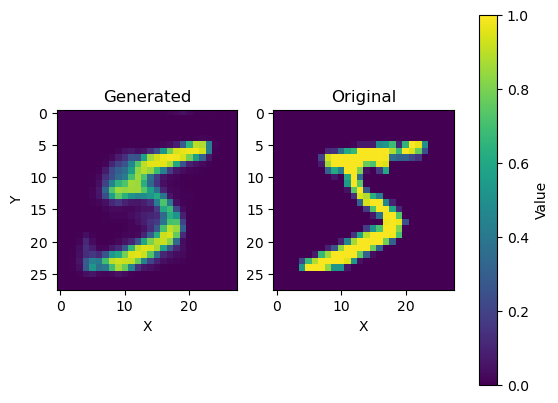

In [10]:
import matplotlib.pyplot as plt

data = [creative_figure.numpy()[0,:,:].sum(axis=2),
        all_digits[0].sum(axis=2)]

plt.figure()
fig, axes = plt.subplots(1, 2)

im = axes[0].imshow(data[0], cmap='viridis', vmin=0, vmax=1)
fig.colorbar(im, ax=axes, label="Value")
axes[0].set_title("Generated")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

im = axes[1].imshow(data[1], cmap='viridis', vmin=0, vmax=1)
axes[1].set_title("Original")
axes[1].set_xlabel("X")
#axes[1].ylabel("Y")

plt.savefig("./generated_epoch_1.png")
plt.show()

<Figure size 640x480 with 0 Axes>

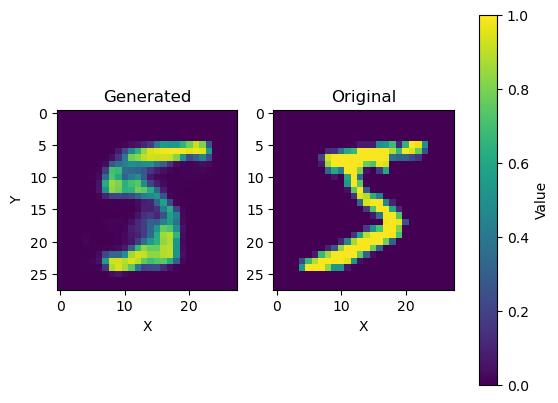

<Figure size 640x480 with 0 Axes>

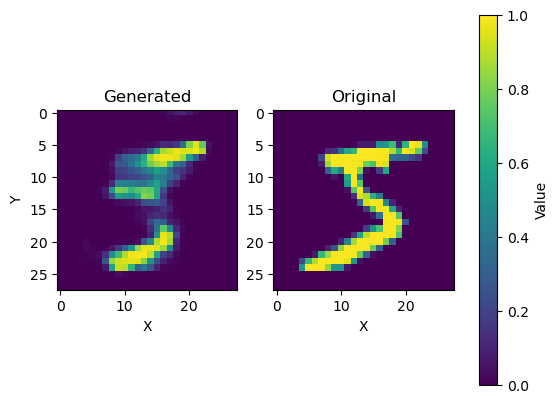

<Figure size 640x480 with 0 Axes>

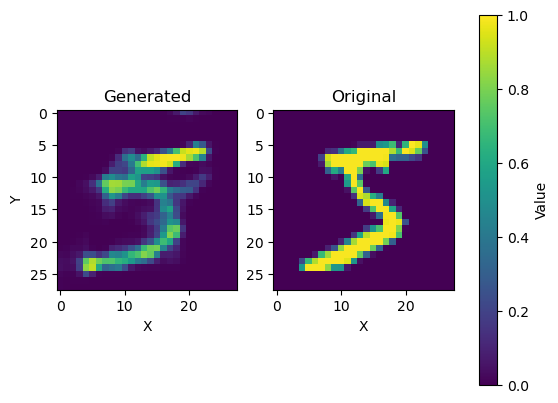

<Figure size 640x480 with 0 Axes>

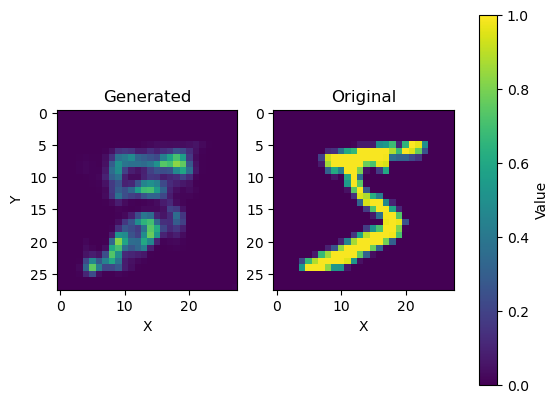

<Figure size 640x480 with 0 Axes>

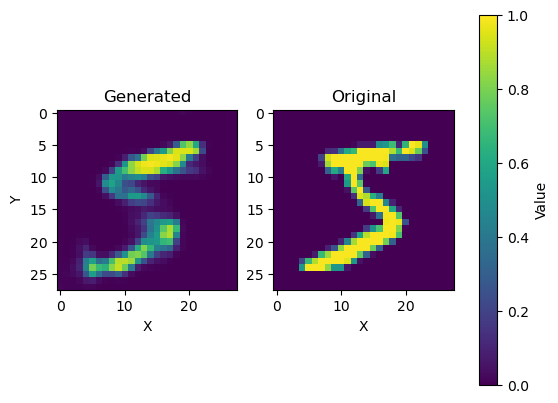

In [11]:
c = 0
original_data = all_digits[0].sum(axis=2)

while c < 5:
    noise = np.random.uniform(low=-0.2, high=0.2, size=l.shape)
    creative_figure = decoder(l + noise, training=False)

    creative_data = creative_figure.numpy()[0,:,:].sum(axis=2)

    plt.figure()
    fig, axes = plt.subplots(1, 2)

    im = axes[0].imshow(creative_data, cmap='viridis', vmin=0, vmax=1)
    fig.colorbar(im, ax=axes, label="Value")
    axes[0].set_title("Generated")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    im = axes[1].imshow(original_data, cmap='viridis', vmin=0, vmax=1)
    axes[1].set_title("Original")
    axes[1].set_xlabel("X")

    plt.savefig(f"./digit_with_noise_{c}.png")
    plt.show()
    c += 1

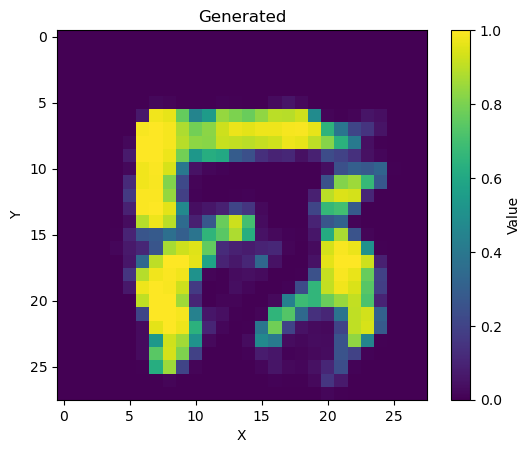

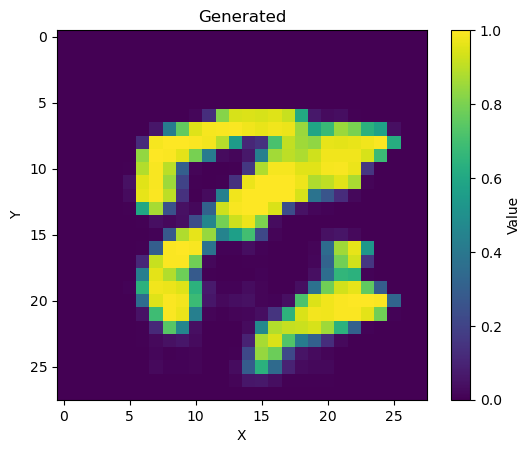

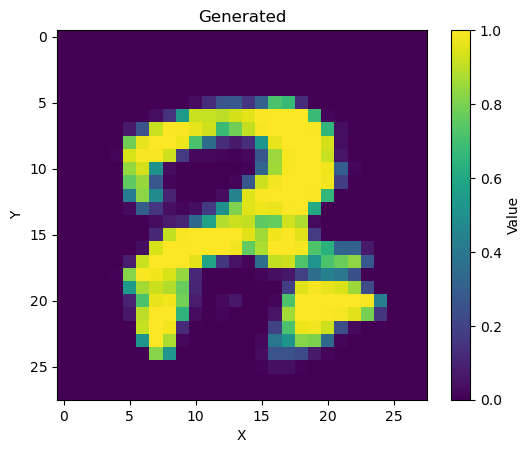

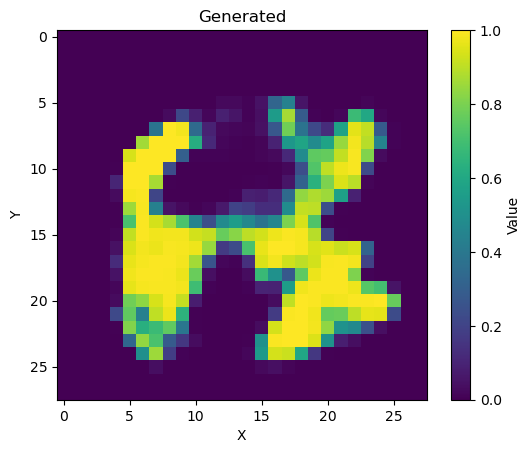

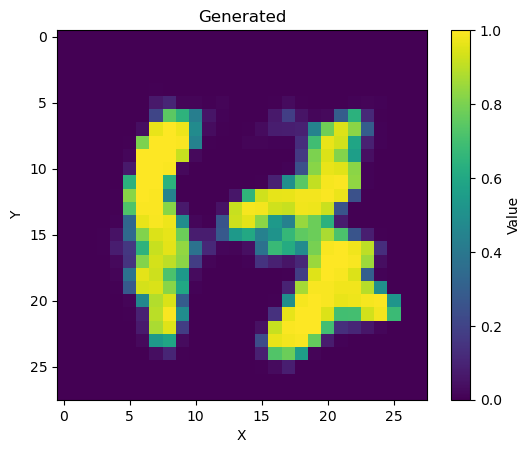

In [12]:
c = 0

while c < 5:
    noise = np.random.uniform(low=0.0, high=1.0, size=l.shape)
    creative_figure = decoder(noise, training=False)

    creative_data = creative_figure.numpy()[0,:,:].sum(axis=2)

    fig = plt.figure()
    

    im = plt.imshow(creative_data, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, label="Value")
    plt.title("Generated")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.savefig(f"./figure_from_noise_{c}.png")
    plt.show()
    c += 1

In [13]:
## Visualizing the latent space 
from sklearn.manifold import TSNE

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


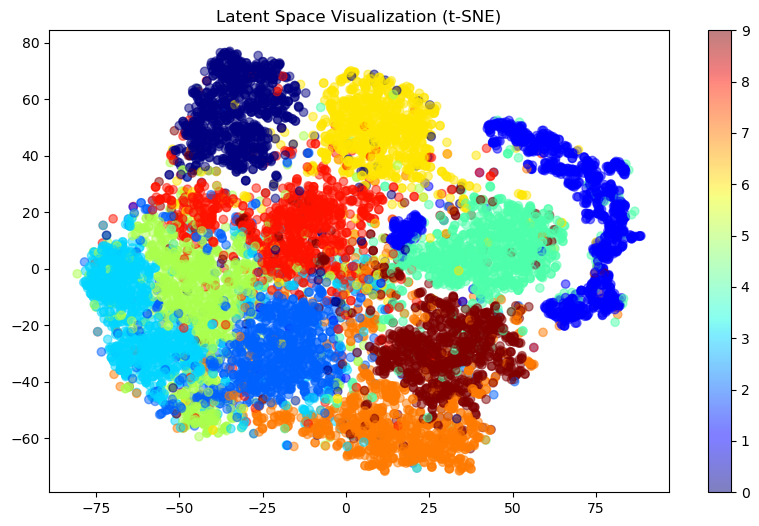

In [14]:
# Get the encoded representations
encoded = keras.layers.Flatten()(x)
encoder = keras.Model(input, encoded)
encoded_images = encoder.predict(x_test[:10000])
# Perform t-SNE
tsne = TSNE(n_components=2)
encoded_2d = tsne.fit_transform(encoded_images)
# Plot the latent space
plt.figure(figsize=(10, 6))
plt.scatter(encoded_2d[:, 0], encoded_2d[:, 1], c=y_test[:10000], cmap='jet', alpha=0.5)
plt.colorbar()
plt.title("Latent Space Visualization (t-SNE)")
plt.show()

In [15]:
## Generating mean and SD for each of the clusters